<a href="https://colab.research.google.com/github/CU-UQ/BF-Stochastic-Subspace-Descent/blob/main/NesterovFcnExample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simplified Demo for Bi-fidelity Stochastic Subspace Descent

This version designed for colab

First, download files from the repo

In [7]:
!wget -nv https://github.com/CU-UQ/BF-Stochastic-Subspace-Descent/raw/refs/heads/main/util/DFO_utilities.py
!wget -nv https://github.com/CU-UQ/BF-Stochastic-Subspace-Descent/raw/refs/heads/main/util/OPT_utilities.py

2026-06-23 14:46:52 URL:https://raw.githubusercontent.com/CU-UQ/BF-Stochastic-Subspace-Descent/refs/heads/main/util/DFO_utilities.py [6750/6750] -> "DFO_utilities.py.1" [1]
2026-06-23 14:46:53 URL:https://raw.githubusercontent.com/CU-UQ/BF-Stochastic-Subspace-Descent/refs/heads/main/util/OPT_utilities.py [29066/29066] -> "OPT_utilities.py.1" [1]


In [8]:
import numpy as np
import matplotlib.pyplot as plt
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
names = {
    'gd': 'GD',
    'cd': 'CD',
    'ssd': 'FS-SSD',
    'spsa': 'SPSA',
    'rgfm': 'GS',
    'ssd_hf': 'HF-SSD',
    'ssd_bf': 'BF-SSD',
    'ssd_oracle': 'O-SSD ',
    'ssd_sag': 'VR-SSD',
    'ssd_py': 'Polyak-SSD',
    'ssd_bf_Hermite': 'BF-SSD-Hermite',
}
colors = {
    'gd': 'tab:blue',
    'cd': 'tab:orange',
    'ssd': 'tab:green',
    'spsa': 'tab:purple',
    'rgfm': 'tab:brown',
    'ssd_hf': 'tab:olive',
    'ssd_bf': 'tab:cyan',
    'ssd_oracle': 'tab:pink',
    'ssd_sag': 'tab:gray',
    'ssd_py': 'tab:red',
    'ssd_bf_Hermite': 'tab:gray',
}
def plot_results_local(
        res,
        bf_ratio=0.0,
        title='Results',
        methods=None,
        index=None):
    plt.figure(figsize=(8,5))
    min_len = min(len(res[k][0]) for k in methods)
    if methods is None: methods = list(colors.keys())
    if index is None: index = 0

    for k in methods:
        color = colors[k]
        min_res = np.minimum.accumulate(res[k], axis=1)
        res_mean = np.mean(min_res, axis=0)
        res_best, res_worst = np.min(min_res, axis=0), np.max(min_res, axis=0)
        leng = len(res_mean)
        min_len = min(min_len, leng)
        t = np.arange(len(res_mean))
        if k == 'ssd_bf':
            t = (1 + bf_ratio) * t
        plt.plot(t[index:min_len], res_mean[index:min_len], label=names[k], color=color, lw=3.0, alpha=0.6)
        plt.fill_between(t[index:min_len], res_best[index:min_len], res_worst[index:min_len], alpha=0.4, color=color)
    plt.yscale('log')
    plt.xlabel('Equivalent HF Function Calls', fontsize=14), plt.ylabel('HF Function value', fontsize=14), plt.legend()
    plt.title(title, fontsize=20)
    plt.xlim(index, min_len)
    plt.tight_layout()

In [9]:
from OPT_utilities import objectiveFcn, grad_desc, coor_desc, ssd, ssd_ls_temp, ssd_bt_temp, ssd_hbt, ssd_sag, spsa, ssd_bt_temp_HermiteInterp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import argparse
def truncate_to_matrix(array_list):
    # Find the minimum length among the arrays
    min_length = min(arr.shape[0] for arr in array_list)

    # Truncate each array to the minimum length and stack them into a matrix
    truncated_matrix = np.vstack([arr[:min_length] for arr in array_list])

    return truncated_matrix

def f_lr(x, lbd, r):
    """Worst function in the world by Nesterov 2013"""
    if r > len(x):
        raise ValueError('r must be less than or equal to the length of x')
    # sums = (x[0]**2 + sum((x[i] - x[i+1])**2 for i in range(0, r-1))
    #         + x[r-1]**2)/2 - x[0]
    # faster code, 2026
    sums = (x[0]**2 + np.linalg.norm(x[:(r-1)] - x[1:r])**2 + x[r-1]**2)/2 - x[0]
    return lbd * sums/4 + lbd * r/(8*(r+1))

lmda = 20. # 'Lambda value'
d   = 1000 # 'Problem Dimension'
r1  = 100  # 'HF Dimension'
r2  = 2    # 'LF Dimension'
ell = 10   # 'Subspace Dimension'
# num_iterations = 10
linesearch_iter = 10
L0 = 1.    # 'Initial Learning Rate for Line Search'
c = 0.9    # 'Armijo Shrinking Factor'
# num_trials = 3

num_iterations = 30

learning_rate = 1 / lmda
learning_rate_ssd = learning_rate * ell / d

# Initialize the worst function
f    = lambda x : f_lr(x, lmda, r1)
f_LF = lambda x : f_lr(x, lmda, r2)
x0  = np.zeros(d)

# Assign function classes
# High-fidelity objective function
obj = objectiveFcn(f,label='Low-rank Function')
# Low-fidelity objective function
obj_lowFi= objectiveFcn(f_LF)
# Alternative High-fidelity objective function (for oracle SSD line search)
obj_alt = objectiveFcn(f)

## Section 4.1 Worst Function in the World

We use an example function
$$f(x; r) = \lambda ((x_1^2 + x_r^2 + \sum_{i=1}^{r-1}(x_i - x_{i+1})^2)/2 - x_1)/4.$$

We set $\lambda =20$, HF function $f(x;100)$ and LF function $f(x;2)$.

In [ ]:
# Run methods
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_lf', 'ssd_hf',
        'ssd_bf', 'ssd_oracle', 'ssd_sag', 'ssd_bf_Hermite']
# methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_lf', 'ssd_hf',
#         'ssd_bf', 'ssd_oracle', 'ssd_sag']
res = {m: [] for m in methods}
num_trials = 5
for i in tqdm(range(num_trials)):
    # Gradient Descent
    if 'gd' in methods:
        _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
        res['gd'].append(obj.returnHistory())
    # Coordinate Descent
    if 'cd' in methods:
        _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
        res['cd'].append(obj.returnHistory())
    # SSD
    if 'ssd' in methods:
        _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
        res['ssd'].append(obj.returnHistory())
    # SPSA
    if 'spsa' in methods:
        _ = spsa(x0,obj,num_iterations=num_iterations*d)
        res['spsa'].append(obj.returnHistory())
    # Random Gradient-free Minimization
    if 'rgfm' in methods:
        _ = ssd(x0,obj,ell=1,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d)
        res['rgfm'].append(obj.returnHistory())
    # SSD with linesearch (LF)
    if 'ssd_lf' in methods:
        _ = ssd_ls_temp(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                    num_iterations=num_iterations*d/ell, linesearch_iter=linesearch_iter )
        res['ssd_lf'].append(obj.returnHistory())
    # SSD with linesearch (HF)
    if 'ssd_oracle' in methods: # typo, listed as ssd_hf ???
        _ = ssd_ls_temp(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
                    num_iterations=num_iterations*d/ell, linesearch_iter=linesearch_iter )
        res['ssd_oracle'].append(obj.returnHistory())
    # SSD with backtracking linesearch (BF)
    if 'ssd_bf' in methods:
        _ = ssd_bt_temp(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,num_iterations=num_iterations*d/ell,
                linesearch_iter=linesearch_iter, L0=L0 )
        res['ssd_bf'].append(obj.returnHistory())
    # SSD with backtracking linesearch (BF, Hermite style)
    if 'ssd_bf_Hermite' in methods:
        _ = ssd_bt_temp_HermiteInterp(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,num_iterations=num_iterations*d/ell,
                linesearch_iter=linesearch_iter, L0=L0 )
        res['ssd_bf_Hermite'].append(obj.returnHistory())
    # SSD with backtracking linesearch (HF)
    if 'ssd_hf' in methods: # typo, listed as ssd_oracle ???
        _ = ssd_hbt(x0,obj,ell=ell,c=c,num_iterations=num_iterations*d/ell,
                    linesearch_iter=linesearch_iter, L0=L0 )
        res['ssd_hf'].append(obj.returnHistory())

    # SSD with SAG
    if 'ssd_sag' in methods:
        _ = ssd_sag(x0,obj,ell=ell,learning_rate=learning_rate_ssd,
                    num_iterations=num_iterations*d/ell)
        res['ssd_sag'].append(obj.returnHistory())
res_copy = res.copy()
print('Done!')

  0%|          | 0/5 [00:00<?, ?it/s]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch, 2026 variant with Hermite interpolation =
======== SSD with HF Backtracking Line Search ========
======== SSD ===================


 20%|██        | 1/5 [00:58<03:52, 58.19s/it]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch, 2026 variant with Hermite interpolation =
======== SSD with HF Backtracking Line Search ========
======== SSD ===================


 40%|████      | 2/5 [01:59<03:00, 60.31s/it]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch, 2026 variant with Hermite interpolation =
======== SSD with HF Backtracking Line Search ========
======== SSD ===================


 60%|██████    | 3/5 [02:59<01:59, 59.76s/it]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =
======== SSD w/ low-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch =
======== SSD w/ backtracking bi-fi linesearch, 2026 variant with Hermite interpolation =
======== SSD with HF Backtracking Line Search ========
======== SSD ===================


 80%|████████  | 4/5 [04:00<01:00, 60.54s/it]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD ===================
======== SSD w/ low-fi linesearch =


In [13]:
# Collect data and compute mean/std
for k, v in res.items():
    res[k] = truncate_to_matrix(v)
bf_ratio = linesearch_iter * r2 / ((ell + 1) * r1)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


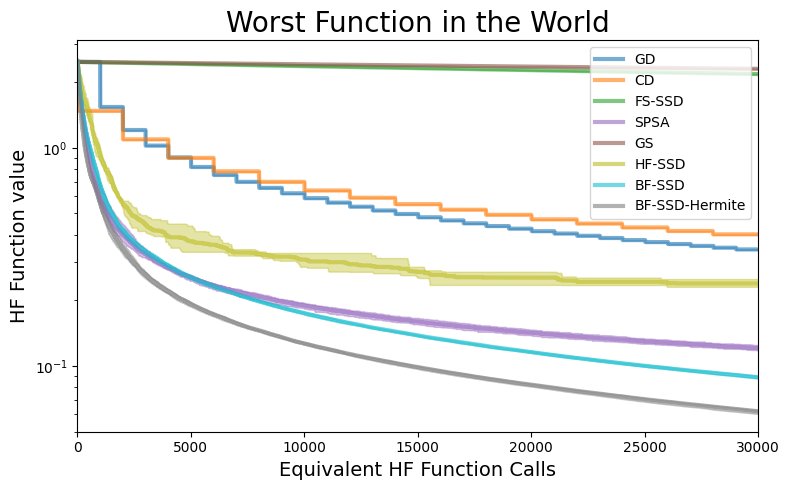

In [14]:
bf_ratio = linesearch_iter * r2 / ((ell + 1) * r1)
# TODO: for the Hermite interpolation, this bf_ratio isn't quite correct
# Also, it's pessimistic since it assumes all steps were taken
# in the low-fi linesearch.

# methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf', 'ssd_sag']
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_hf', 'ssd_bf','ssd_bf_Hermite']
plot_results_local(res, bf_ratio=bf_ratio, title='Worst Function in the World', methods=methods)